In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
donegal_df = pd.read_excel("C:/Users/22358313/Desktop/University/BSc Fourth Year/FYP/Election_Data_CSVs/general_election_2020_count_details.xlsx",
                           engine='openpyxl',
                           sheet_name = "Donegal")

In [36]:
gw_df = pd.read_excel("C:/Users/22358313/Desktop/University/BSc Fourth Year/FYP/Election_Data_CSVs/general_election_2020_count_details.xlsx",
                           engine='openpyxl',
                           sheet_name = "Galway West")

In [68]:
def proportion_per_count(df):
    
    count_lst = list(df["Count Number"].unique())
    count_lst.remove(1)
    #--Filter by count
    propn = []
    for count in count_lst:
        filtered_df1 = df[df["Count Number"]==count]
        
        src_cands = filtered_df1[filtered_df1["Transfers"]<0]
        
        non_t = np.abs(np.sum(list(src_cands["Non-Transferable"].values)))
        total_transfers = np.abs(np.sum(list(src_cands["Transfers"].values)))
        propn_count = non_t/(total_transfers+non_t)
        #DEBUG: print(total_transfers+non_t)
        propn.append(propn_count)
    #print(propn)
    bar_chart(count_lst,propn)
    

In [69]:
def bar_chart(ct_lst,vals_lst):
    plt.bar(ct_lst, vals_lst, color='skyblue')
    plt.title('Proportion of Non-transferable Votes Per Count')
    plt.xlabel('Count')
    plt.ylabel('Proportion')
    plt.show()

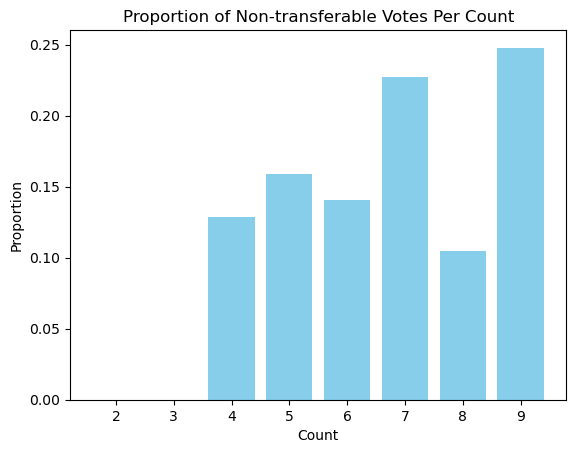

In [70]:
proportion_per_count(donegal_df)

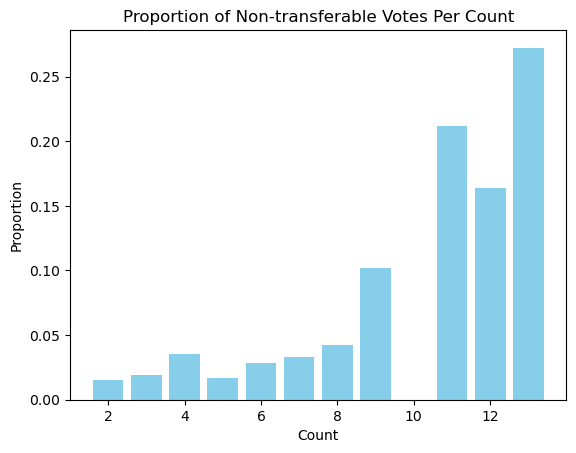

In [71]:
proportion_per_count(gw_df)

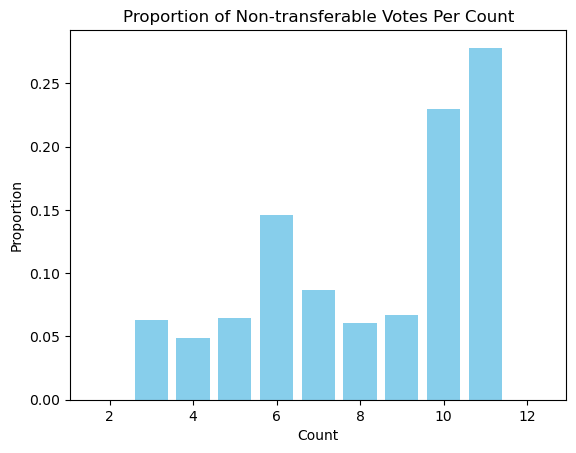

In [72]:
proportion_per_count(fingal_df)

In [57]:
def proportion_overall(df):
    count_lst = list(df["Count Number"].unique())
    count_lst.remove(1)
    
    filtered_df = df[df["Transfers"]<0]
    
    non_t = np.sum(list(filtered_df["Non-Transferable"].values))
    total_transfers = np.abs(np.sum(list(filtered_df["Transfers"].values)))
    propn = non_t/(total_transfers+non_t)
    return propn

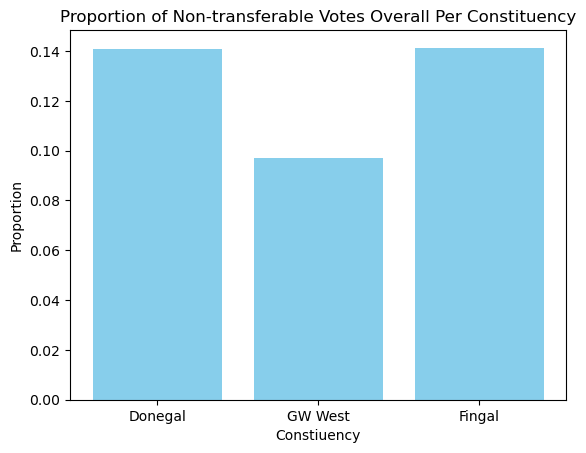

In [67]:
donegal_propn = proportion_overall(donegal_df)
gw_west_propn = proportion_overall(gw_df)
fingal_propn = proportion_overall(fingal_df)

propns = [donegal_propn,gw_west_propn,fingal_propn]
constit_name = ["Donegal","GW West","Fingal"]

plt.bar(constit_name, propns, color='skyblue')
plt.title('Proportion of Non-transferable Votes Overall Per Constituency')
plt.xlabel('Constituency')
plt.ylabel('Proportion')
plt.show()